# XL-sized Inversions
Here, we visualize the inversions that were identified for the `xl` treatment across the range of depths.

In [2]:
library(ggplot2)

read_data <- function(size_treatment, depth){
    truthfile <- paste0("simulated_data/inversions/", size_treatment, "/inv.", size_treatment,".vcf")
    samplesfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth , "by_sample/inversions.bedpe", sep = "/")
    poolfile <- paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_pop/inversions.bedpe", sep = "/")

    true_inversions <- read.table(truthfile, header = F)[,c(1,2,8)]
    true_inversions$V8 <- as.numeric(unlist(lapply(true_inversions$V8, function(X){gsub(".+END=", "", X)})))
    names(true_inversions) <- c("contig", "position_start", "position_end")
    true_inversions$sample <- "simulated_inversions"

    sample_inversions <- read.table(
        paste("simulated_data/called_sv/leviathan", size_treatment, depth, "by_sample/inversions.bedpe", sep = "/"),
        header = T
    )[,1:4]

    pooled_inversions <- read.table(poolfile, header = T)
    pooled_inversions <- pooled_inversions[,c("population","contig", "position_start", "position_end")]
    names(pooled_inversions)[1] <- "sample"
    if( nrow(pooled_inversions) > 0){
        pooled_inversions$sample <- paste("pooled", depth, size_treatment, sep = "_")
    }

    return(
        rbind(true_inversions, sample_inversions, pooled_inversions)
    )
}

plot_data <- function(data, size_treatment, depth){
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        labs(title = "Called Inversions", subtitle = paste(size_treatment, depth), x = "genomic position (bp)", caption = "Simulated inversions (groundtruth) shown in top row") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

Set a global variable `.size` to `"xl"` to avoid writing it each time

In [3]:
.size <- "xl"

## 0.5X depth

In [4]:
depth_05X <- read_data(.size, "05X")
depth_05X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,961650,21551190,simulated_inversions
2R,6686007,24798525,simulated_inversions
3L,5332918,22935558,simulated_inversions
3R,5316416,31441385,simulated_inversions


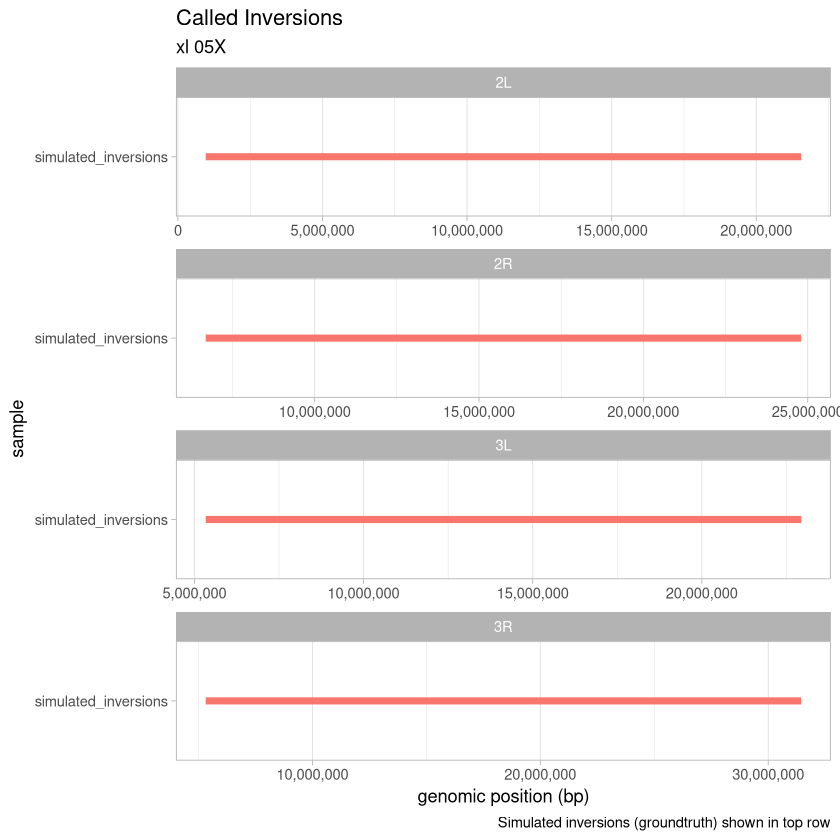

In [5]:
plot_data(depth_05X, .size, "05X")

## 2X Depth

In [6]:
depth_2X <- read_data(.size, "2X")
depth_2X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,961650,21551190,simulated_inversions
2R,6686007,24798525,simulated_inversions
3L,5332918,22935558,simulated_inversions
3R,5316416,31441385,simulated_inversions
3R,5332917,22935558,sample_02.2X
2R,6686006,24798524,sample_07.2X
2R,6686007,24798525,sample_05.2X
3R,5332917,22935558,sample_05.2X
3L,5332915,22935558,sample_09.2X


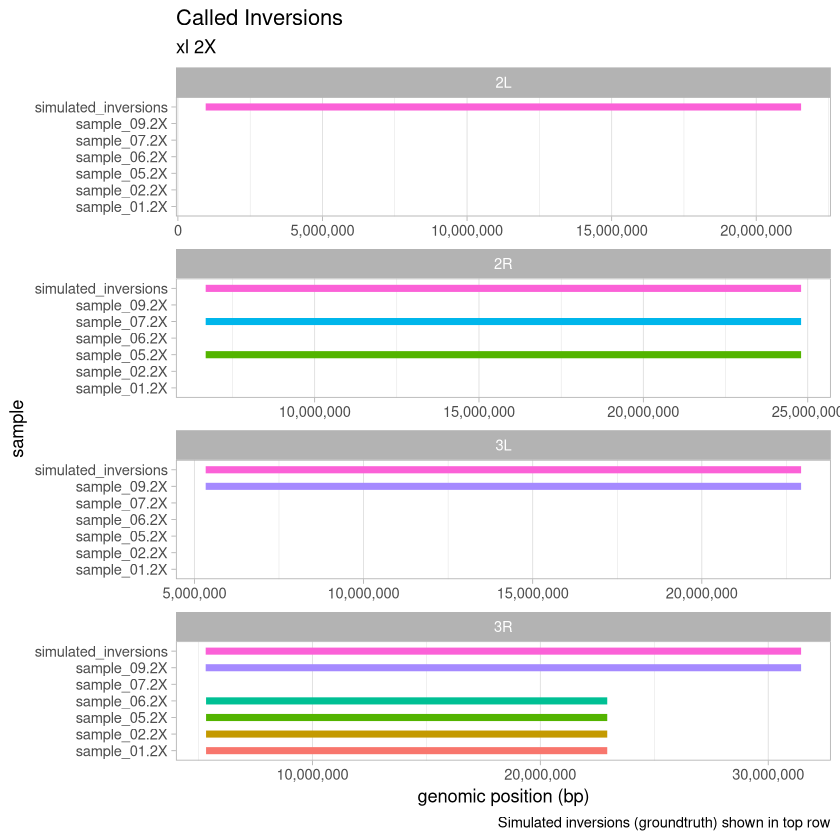

In [7]:
plot_data(depth_2X, .size, "2X")

## 5X Depth

In [8]:
depth_5X <- read_data(.size, "5X")
depth_5X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,961650,21551190,simulated_inversions
2R,6686007,24798525,simulated_inversions
3L,5332918,22935558,simulated_inversions
3R,5316416,31441385,simulated_inversions
3R,5332917,22935558,sample_10.5X
2R,6686007,24798525,sample_05.5X
3R,5332917,22935558,sample_05.5X
3L,5332915,22935560,sample_09.5X
2R,6686006,24798525,sample_09.5X


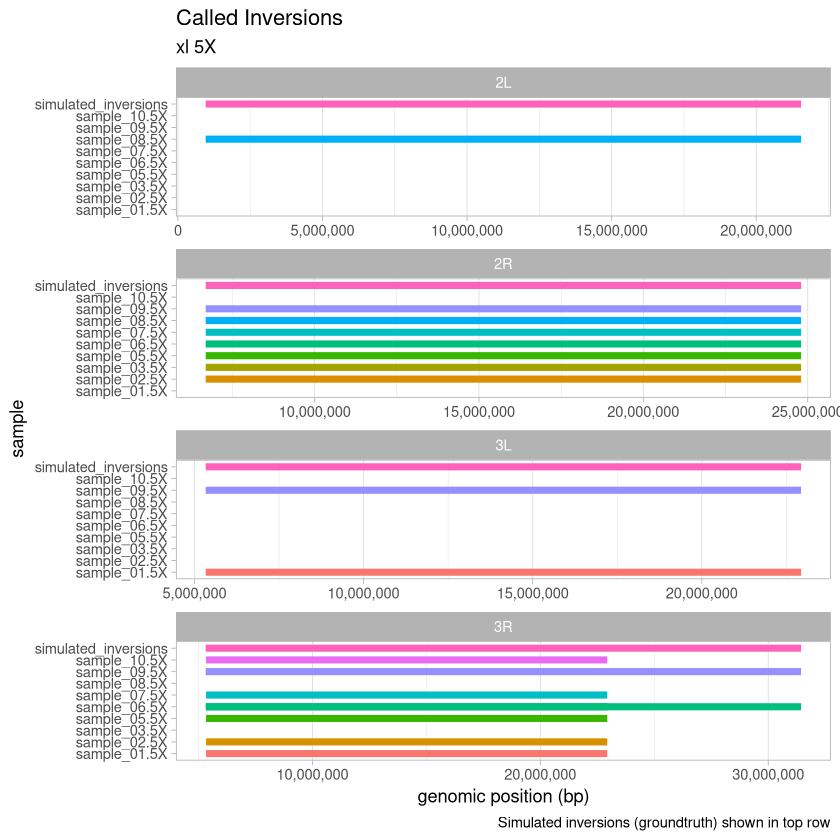

In [9]:
plot_data(depth_5X, .size, "5X")

## 10X Depth

In [10]:
depth_10X <- read_data(.size, "10X")
depth_10X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,961650,21551190,simulated_inversions
2R,6686007,24798525,simulated_inversions
3L,5332918,22935558,simulated_inversions
3R,5316416,31441385,simulated_inversions
2L,961650,21551190,sample_05.10X
2R,6686006,24798524,sample_05.10X
3R,5332917,22935558,sample_05.10X
2R,6686006,24798524,sample_07.10X
3R,5332917,22935558,sample_07.10X


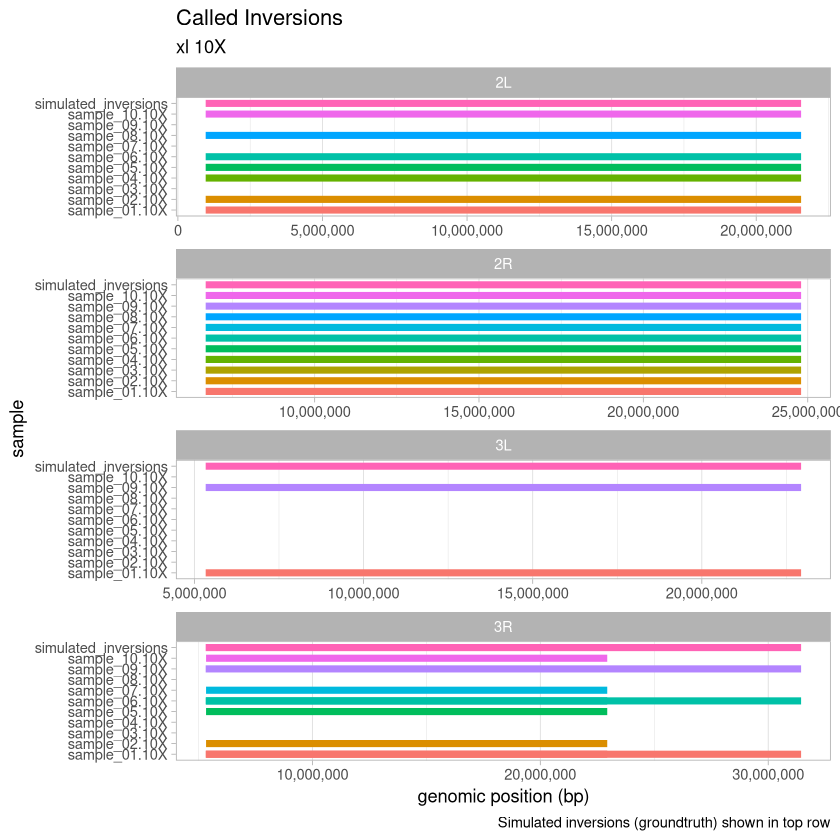

In [11]:
plot_data(depth_10X, .size, "10X")

## 20X Depth

In [12]:
depth_20X <- read_data(.size, "20X")
depth_20X

contig,position_start,position_end,sample
<chr>,<int>,<dbl>,<chr>
2L,961650,21551190,simulated_inversions
2R,6686007,24798525,simulated_inversions
3L,5332918,22935558,simulated_inversions
3R,5316416,31441385,simulated_inversions
2R,6686007,24798524,sample_03.20X
3R,5332917,22935558,sample_03.20X
3L,5332915,22935560,sample_09.20X
2R,6686006,24798524,sample_09.20X
3R,5316415,31441385,sample_09.20X


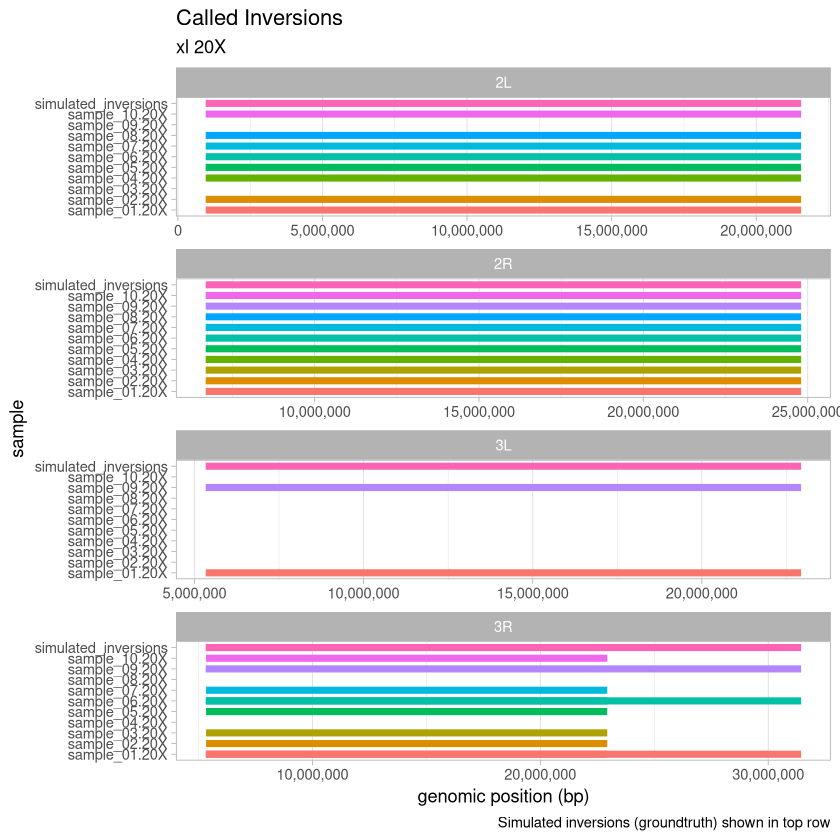

In [13]:
plot_data(depth_20X, .size, "20X")